# Week 6 — Day 2: PyTorch nn.Module — Proper Neural Network Structure

## Goal
Build a proper neural network using nn.Module with BatchNorm and Dropout.
Compare with Day 1 results.

---

## Key Concepts

### nn.Module
Base class for all PyTorch neural networks. Every custom model must
inherit from it. super().__init__() initializes the parent class so
PyTorch can track all layers, parameters, and gradients automatically.
Without it PyTorch doesn't know your class is a neural network.

### nn.Sequential
Chains layers in order — input flows through each layer one by one.
First Linear → then ReLU → then next Linear etc. Clean way to define
simple networks without writing forward() manually for each layer.

### Why Sigmoid at output (not ReLU)
Sigmoid squishes output to 0-1 range = probability.
Binary classification needs a probability — is this passenger alive (1)
or dead (0)? ReLU would give unbounded positive numbers, not probabilities.

---

## Network Architecture

```python
class TitanicNetV2(nn.Module):
    def __init__(self, input_size):
        super(TitanicNetV2, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze()
```

**Total parameters: ~12,000**

### What BatchNorm does
Normalizes the outputs of each layer to have mean=0, std=1.
Stabilizes training — gradients flow better, learning is faster.
Reduces sensitivity to weight initialization.

### What Dropout does
Randomly sets neurons to 0 during training (0.4 = 40% chance).
Forces network to not rely on any single neuron — reduces overfitting.
Disabled during evaluation with model.eval().

---

## Features Used
```python
features = ['Pclass', 'Sex', 'Age', 'Fare',
            'FamilySize', 'IsAlone', 'Title', 'Embarked']
```
Added engineered features from Day 1 — FamilySize, IsAlone, Title.

---

## Training Loop Structure

```python
for epoch in range(epochs):
    # training phase
    model.train()          # enable dropout + batchnorm training mode
    optimizer.zero_grad()  # reset gradients — must do every epoch
    preds = model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()        # compute gradients
    optimizer.step()       # update weights

    # validation phase
    model.eval()           # disable dropout
    with torch.no_grad():  # no gradient tracking — saves memory
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t)
```

**Why optimizer.zero_grad() every epoch?**
PyTorch accumulates gradients by default. Without resetting, gradients
from previous step add to current step — wrong update direction.

**Why torch.no_grad() during validation?**
No weight updates during validation — no need to track gradients.
Saves memory and speeds up evaluation.

---

## Training Results

| Epoch | Train Loss | Val Loss | Train Acc | Val Acc |
|---|---|---|---|---|
| 10 | 0.5270 | 0.6122 | 77.81% | 75.42% |
| 30 | 0.4486 | 0.4615 | 81.88% | 79.89% |
| 60 | 0.4124 | 0.4274 | 83.57% | 83.80% |
| 100 | 0.4013 | 0.4242 | 83.01% | 81.56% |

**Best val accuracy: 83.80% at epoch 56**
**Final val accuracy: 81.56%**

---

## Learning Curve Analysis

- Val loss stops improving significantly after epoch ~60
- Small gap between train acc (83%) and val acc (81%) — well fitted model
- Slight drop after epoch 60 — mild overfitting but nothing serious
- BatchNorm + Dropout kept train/val curves close together

**Overfitting check:**
- Overfitting = train acc 95%+, val acc stays low ❌ not happening
- Underfitting = both below 75% ❌ not happening
- Well fitted = small gap, both improving together ✅

---

## Model Comparison

| Model | Accuracy |
|---|---|
| Logistic Regression (5-fold CV) | 81.59% |
| Random Forest (5-fold CV) | 80.36% |
| Neural Network Day 1 | 83.24% |
| Neural Network Day 2 (BatchNorm+Dropout) | 83.80% ✅ |

---

## Key Takeaways
- nn.Module is the base for every PyTorch model — always inherit from it
- Training loop pattern: zero_grad → forward → loss → backward → step
- model.train() vs model.eval() — must switch between training and validation
- BatchNorm stabilizes training, Dropout reduces overfitting
- Best model checkpoint should be saved at best val accuracy not final epoch
- Val loss flattening = signal to stop training (early stopping)
- Next: Day 3 — activation functions + optimizers comparison

# Improved neural network with BatchNorm:

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# ── Load Titanic data (same as Day 1) ────────────────────────
df = pd.read_csv('train.csv')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Title']      = df['Name'].apply(
                       lambda name: name.split(',')[1]
                                        .split('.')[0].strip())
df['Title']      = df['Title'].map({
                       'Mr': 0, 'Miss': 1, 'Mrs': 2,
                       'Master': 3}).fillna(4)
df['Sex']        = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked']   = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

features = ['Pclass', 'Sex', 'Age', 'Fare',
            'FamilySize', 'IsAlone', 'Title', 'Embarked']

X = df[features].values
y = df['Survived'].values

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_t = torch.FloatTensor(X_train)
X_val_t   = torch.FloatTensor(X_val)
y_train_t = torch.FloatTensor(y_train)
y_val_t   = torch.FloatTensor(y_val)

# ── Improved Network with BatchNorm ──────────────────────────
class TitanicNetV2(nn.Module):
    def __init__(self, input_size):
        super(TitanicNetV2, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),       # normalize layer outputs
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

model_v2 = TitanicNetV2(input_size=8)
criterion = nn.BCELoss()              # binary cross entropy loss
optimizer = optim.Adam(model_v2.parameters(), lr=0.001)
print(model_v2)
print(f"\nTotal parameters: {sum(p.numel() for p in model_v2.parameters()):,}")

TitanicNetV2(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters: 11,969


# Training Loop:

In [5]:
# ── Training Loop ─────────────────────────────────────────────
epochs        = 100
train_losses  = []
val_losses    = []
train_accs    = []
val_accs      = []

for epoch in range(epochs):
    # ── Training phase ────────────────────────────────────────
    model_v2.train()                          # enable dropout
    optimizer.zero_grad()                  # zero gradients

    # forward pass
    train_preds = model_v2(X_train_t)
    train_loss  = criterion(train_preds, y_train_t)

    # backward pass
    train_loss.backward()
    optimizer.step()                       # update weights

    # training accuracy
    train_acc = ((train_preds > 0.5) == y_train_t.bool()).float().mean()

    # ── Validation phase ──────────────────────────────────────
    model_v2.eval()                           # disable dropout
    with torch.no_grad():                  # no gradient tracking
        val_preds = model_v2(X_val_t)
        val_loss  = criterion(val_preds, y_val_t)
        val_acc   = ((val_preds > 0.5) == y_val_t.bool()).float().mean()

    # store history
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

    # print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {train_loss.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f} | "
              f"Train Acc: {train_acc.item():.4f} | "
              f"Val Acc: {val_acc.item():.4f}")

print(f"\nFinal Val Accuracy: {val_accs[-1]:.4f}")

Epoch  10 | Train Loss: 0.5270 | Val Loss: 0.6122 | Train Acc: 0.7781 | Val Acc: 0.7542
Epoch  20 | Train Loss: 0.4777 | Val Loss: 0.5130 | Train Acc: 0.7963 | Val Acc: 0.7821
Epoch  30 | Train Loss: 0.4486 | Val Loss: 0.4615 | Train Acc: 0.8188 | Val Acc: 0.7989
Epoch  40 | Train Loss: 0.4382 | Val Loss: 0.4394 | Train Acc: 0.8188 | Val Acc: 0.7989
Epoch  50 | Train Loss: 0.4102 | Val Loss: 0.4302 | Train Acc: 0.8329 | Val Acc: 0.8156
Epoch  60 | Train Loss: 0.4124 | Val Loss: 0.4274 | Train Acc: 0.8357 | Val Acc: 0.8380
Epoch  70 | Train Loss: 0.4120 | Val Loss: 0.4260 | Train Acc: 0.8315 | Val Acc: 0.8212
Epoch  80 | Train Loss: 0.4135 | Val Loss: 0.4258 | Train Acc: 0.8188 | Val Acc: 0.8156
Epoch  90 | Train Loss: 0.4142 | Val Loss: 0.4252 | Train Acc: 0.8216 | Val Acc: 0.8212
Epoch 100 | Train Loss: 0.4013 | Val Loss: 0.4242 | Train Acc: 0.8301 | Val Acc: 0.8156

Final Val Accuracy: 0.8156


# Plot loss and accuracy curves:

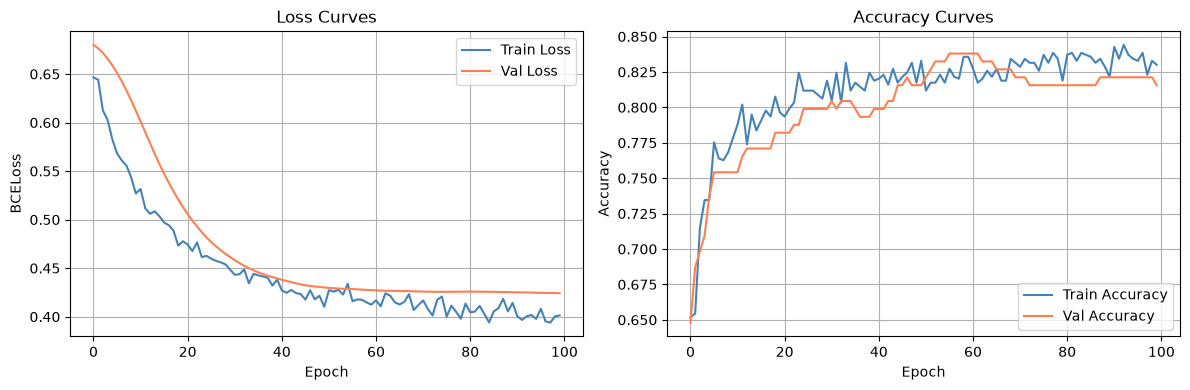

Best val accuracy : 0.8380 at epoch 56
Final val accuracy: 0.8156


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss curves
axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='coral')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCELoss')
axes[0].legend()
axes[0].grid(True)

# accuracy curves
axes[1].plot(train_accs, label='Train Accuracy', color='steelblue')
axes[1].plot(val_accs,   label='Val Accuracy',   color='coral')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('nn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best val accuracy : {max(val_accs):.4f} at epoch {val_accs.index(max(val_accs))+1}")
print(f"Final val accuracy: {val_accs[-1]:.4f}")